In [ ]:
import DistanceBased.similarities as S

# Seputar Dataset

#### Inisiasi Dataset menggunakan object MatrixRating

In [1]:
from MatrixRating import MatrixRating as m

data = m("data/ml-100k")

In [ ]:
from itertools import product
import numpy as np

for fold,i in product(range(len(data.train)),range((data.numberOfUser))) :
    if i%100 == 0 :
        print(f"Index = {fold}, sim({i})")
    for u in range(data.numberOfUser) :
        array_a = np.array(data.getItem(i,indexFold=fold))
        array_b = np.array(data.getItem(u,indexFold=fold))
        
        bc = [len(array_a[array_a == i])/len(array_a) * len(array_b[array_b == i])/len(array_b)  for i in [1,2,3,4,5]]

        jac = set(data.getItem(i,indexFold=fold)).intersection(data.getItem(u,indexFold=fold))
            # print(sum(bc))
            # print(jac)

    # print(list(filter(lambda x : x==1,data.getItem(i,indexFold=fold))))

Index = 0, sim(0)
Index = 0, sim(100)
Index = 0, sim(200)
Index = 0, sim(300)
Index = 0, sim(400)
Index = 0, sim(500)
Index = 0, sim(600)
Index = 0, sim(700)
Index = 0, sim(800)
Index = 0, sim(900)
Index = 1, sim(0)
Index = 1, sim(100)
Index = 1, sim(200)
Index = 1, sim(300)
Index = 1, sim(400)
Index = 1, sim(500)
Index = 1, sim(600)
Index = 1, sim(700)
Index = 1, sim(800)
Index = 1, sim(900)
Index = 2, sim(0)
Index = 2, sim(100)
Index = 2, sim(200)
Index = 2, sim(300)
Index = 2, sim(400)
Index = 2, sim(500)
Index = 2, sim(600)
Index = 2, sim(700)
Index = 2, sim(800)
Index = 2, sim(900)
Index = 3, sim(0)
Index = 3, sim(100)
Index = 3, sim(200)
Index = 3, sim(300)
Index = 3, sim(400)
Index = 3, sim(500)
Index = 3, sim(600)
Index = 3, sim(700)
Index = 3, sim(800)
Index = 3, sim(900)
Index = 4, sim(0)
Index = 4, sim(100)
Index = 4, sim(200)
Index = 4, sim(300)
Index = 4, sim(400)
Index = 4, sim(500)
Index = 4, sim(600)
Index = 4, sim(700)
Index = 4, sim(800)
Index = 4, sim(900)


#### Deskripsi dataset

In [3]:
print(len(data.getItemTest(1,indexTrain=0)))
print((data.getItemTest(2,indexTrain=4)))
print(len(data.getUniqueIdOfUserTest(indexTrain=4)))
print(len(data.getUniqueIdOfUserTrain(indexTrain=0)))

22
[339, 345, 352]
927
943


In [8]:
import numpy as np

transform = np.array(data.transformationData(data.dataset)).tolist()

print("Jumlah rating pada dataset =", data.checkNumberOfRating(transform))
print("Jumlah item =", data.numberOfItem)
print("Jumlah user =", data.numberOfUser)
print("Id Item tertinggi =", data.maxIdOfItem)
print("Id User tertinggi =", data.maxIdOfUser)

Jumlah rating pada dataset = 100000
Jumlah item = 1682
Jumlah user = 943
Id Item tertinggi = 1682
Id User tertinggi = 943


#### Deskripsi data training setiap fold

In [4]:
import pandas as pd

training = data.train
test = data.test

for index,matrix in zip(range(1,6),training) :
    df = pd.read_csv(f"data/ml-100k/u{index}.base",sep="\t", names=["user_id","item_id","rating","timestamp"])

    if index == 1 :
        print("_____________________________________________________")

    print(f"Train k-{index}")
    print("_____________________________________________________")
    print("Max Unique Id user =", max(pd.unique(df["user_id"])))
    print("Max Unique Id item = ", max(pd.unique(df["item_id"])))
    print("number of user = ", len(pd.unique(df["user_id"])))
    print("number of item = ", len(pd.unique(df["item_id"])))
    print(f"number rating = ", data.checkNumberOfRating(matrix))
    print("_____________________________________________________")


_____________________________________________________
Train k-1
_____________________________________________________
Max Unique Id user = 943
Max Unique Id item =  1682
number of user =  943
number of item =  1650
number rating =  80000
_____________________________________________________
Train k-2
_____________________________________________________
Max Unique Id user = 943
Max Unique Id item =  1682
number of user =  943
number of item =  1648
number rating =  80000
_____________________________________________________
Train k-3
_____________________________________________________
Max Unique Id user = 943
Max Unique Id item =  1682
number of user =  943
number of item =  1650
number rating =  80000
_____________________________________________________
Train k-4
_____________________________________________________
Max Unique Id user = 943
Max Unique Id item =  1682
number of user =  943
number of item =  1660
number rating =  80000
________________________________________________

#### Deskripsi data test setiap fold

In [5]:
for index,matrix in zip(range(1,6),test) :
    df = pd.read_csv(f"data/ml-100k/u{index}.test",sep="\t", names=["user_id","item_id","rating","timestamp"])

    if index == 1 :
        print("_____________________________________________")
    print(f"Test k-{index}")
    print("_____________________________________________")
    print("Unik Id tertinggi user =", max(pd.unique(df["user_id"])))
    print("Unik Id tertinggi item = ", max(pd.unique(df["item_id"])))
    print("Jumlah user = ", len(pd.unique(df["user_id"])))
    print("Jumlah item = ", len(pd.unique(df["item_id"])))
    print(f"Jumlah rating = ", data.checkNumberOfRating(matrix))
    print("_____________________________________________")

_____________________________________________
Test k-1
_____________________________________________
Unik Id tertinggi user = 462
Unik Id tertinggi item =  1591
Jumlah user =  459
Jumlah item =  1410
Jumlah rating =  20000
_____________________________________________
Test k-2
_____________________________________________
Unik Id tertinggi user = 658
Unik Id tertinggi item =  1624
Jumlah user =  653
Jumlah item =  1420
Jumlah rating =  20000
_____________________________________________
Test k-3
_____________________________________________
Unik Id tertinggi user = 877
Unik Id tertinggi item =  1669
Jumlah user =  869
Jumlah item =  1423
Jumlah rating =  20000
_____________________________________________
Test k-4
_____________________________________________
Unik Id tertinggi user = 943
Unik Id tertinggi item =  1679
Jumlah user =  923
Jumlah item =  1394
Jumlah rating =  20000
_____________________________________________
Test k-5
_____________________________________________
Unik Id

# Tversky Index

In [1]:
import DistanceBased.similarities as S
from tqdm.contrib.itertools import product

opsional = ["user-based","item-based"]
alpha_1 = [0.1,0.2]
alpha_2 = [0.5]

top_k = [5,10,15,18,20,25,30,40,50,100,200]

for opsional_index,i,j,k in product(opsional,alpha_1,alpha_2,top_k) :
    # print(f"alpha_1 = {i} & alpha_2 = {j}")
    S.TI("data/ml-100k",k=k,opsional=opsional_index,alpha_1=i,alpha_2=j)

# ti = S.TI("data/ml-100k",k=5,opsional="user-based",alpha_1=0.2,alpha_2=0.5)

  0%|          | 0/44 [00:00<?, ?it/s]

In [1]:
import DistanceBased.similarities as S
from hybrid import HCF

hybrid = HCF("data/ml-100k",object=S.TI,k_user=20,k_item=30,gamma=0.7,toyData=False,N=20,n=20,alpha_1=0.1,alpha_2=0.1)

### Skenario 1 : Mencari $\alpha_1$ dan $\alpha_2$ terbaik

In [34]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S

param = {
            "gamma" : [0.7],
            "k_user" : [20],
            "k_item" : [30],
            "alpha_1" : [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
            "alpha_2" : [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
        }

skenario_pertama = EksperimenHCF("data/ml-100k",object=S.TI,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],alpha_1=param["alpha_1"],alpha_2=param["alpha_2"],path_file="Eksperimen/tversky_index/FBO_A1_and_A2_v2.joblib",N=20,n=20)

In [52]:
import numpy as np

n = 20
idcg = np.array([sum(np.array([sum(1/np.log2(np.arange(2,n+2))) for n in range(1,n+1)])) for i in range(1,n+1)])


mean_dcg = []
mean_dcg_fold = []
mean_ndcg = []
mean_ndcg_fold = []

for alpha_1_index in skenario_pertama.result_skenario[0.7][20][30] :

    skenario_pertama_alpha_1 = skenario_pertama.result_skenario[0.7][20][30][alpha_1_index]
    for alpha_2_index in skenario_pertama_alpha_1 :
        mean_dcg_per_fold = []
        mean_ndcg_per_fold = []

        for i in range(len(skenario_pertama_alpha_1[0])) :
            mean_dcg_per_fold += [sum(skenario_pertama_alpha_1[alpha_2_index][i])/len(skenario_pertama_alpha_1[alpha_2_index][i])]
            mean_ndcg_per_fold += [sum(np.array(skenario_pertama_alpha_1[alpha_2_index][i])/idcg[n-1])/len(skenario_pertama_alpha_1[alpha_2_index][i])]
        
        mean_dcg_per_fold += [sum(mean_dcg_per_fold)/len(skenario_pertama_alpha_1)]
        mean_ndcg_per_fold += [sum(mean_ndcg_per_fold)/len(skenario_pertama_alpha_1)]

        mean_dcg_fold += [mean_dcg_per_fold]
        mean_ndcg_fold += [mean_ndcg_per_fold]
        mean_dcg += [[alpha_1_index,alpha_2_index,sum(mean_dcg_per_fold)/len(skenario_pertama_alpha_1)]]
        mean_ndcg += [[alpha_1_index,alpha_2_index,sum(mean_ndcg_per_fold)/len(skenario_pertama_alpha_1)]]

#### DCG per fold

In [61]:
import pandas as pd
import itertools
alpha = [round(i*0.1,2) for i in range(11)]

pd.DataFrame(mean_dcg_fold,index=[ f"A1_{str(i)}_A2_{str(j)}" for i,j in itertools.product(alpha,alpha)],columns=[f"Fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,Fold-1,Fold-2,Fold-3,Fold-4,Fold-5,rata-rata
A1_0.0_A2_0.0,1.483601,1.381528,0.890230,0.711363,0.827350,0.481279
A1_0.0_A2_0.1,1.357035,0.667028,0.430665,0.515717,0.280681,0.295557
A1_0.0_A2_0.2,1.338256,0.649562,0.408540,0.507570,0.267324,0.288296
A1_0.0_A2_0.3,1.354280,0.638753,0.410196,0.501866,0.238743,0.285803
A1_0.0_A2_0.4,1.296982,0.638384,0.411812,0.517298,0.239691,0.282197
...,...,...,...,...,...,...
A1_1.0_A2_0.6,3.587243,1.715307,1.317091,1.427168,0.690276,0.794280
A1_1.0_A2_0.7,3.525385,1.728623,1.256647,1.456203,0.655000,0.783805
A1_1.0_A2_0.8,3.365592,1.705574,1.248892,1.361203,0.674986,0.759659
A1_1.0_A2_0.9,3.299401,1.717581,1.210623,1.351560,0.660649,0.749074


#### NDCG per fold

In [60]:
import pandas as pd
import itertools
alpha = [round(i*0.1,2) for i in range(11)]

pd.DataFrame(mean_ndcg_fold,index=[ f"A1_{str(i)}_A2_{str(j)}" for i,j in itertools.product(alpha,alpha)],columns=[f"Fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,Fold-1,Fold-2,Fold-3,Fold-4,Fold-5,rata-rata
A1_0.0_A2_0.0,0.016559,0.015420,0.009936,0.007940,0.009234,0.005372
A1_0.0_A2_0.1,0.015146,0.007445,0.004807,0.005756,0.003133,0.003299
A1_0.0_A2_0.2,0.014937,0.007250,0.004560,0.005665,0.002984,0.003218
A1_0.0_A2_0.3,0.015116,0.007129,0.004578,0.005601,0.002665,0.003190
A1_0.0_A2_0.4,0.014476,0.007125,0.004596,0.005774,0.002675,0.003150
...,...,...,...,...,...,...
A1_1.0_A2_0.6,0.040038,0.019145,0.014700,0.015929,0.007704,0.008865
A1_1.0_A2_0.7,0.039348,0.019294,0.014026,0.016253,0.007311,0.008748
A1_1.0_A2_0.8,0.037564,0.019036,0.013939,0.015193,0.007534,0.008479
A1_1.0_A2_0.9,0.036826,0.019170,0.013512,0.015085,0.007374,0.008361


#### DCG $\alpha_1$ dan $\alpha_2$ Plot

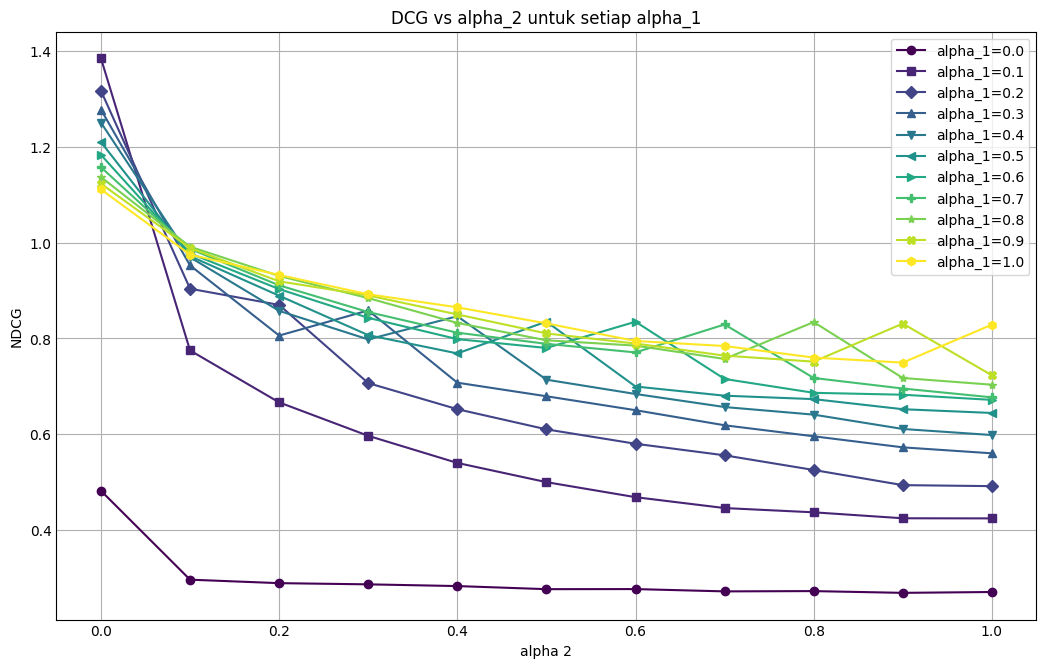

In [127]:
import pandas as pd

df = pd.DataFrame(mean_dcg, index=[i for i in range(1, len(mean_dcg) + 1)], columns=["alpha 1", "alpha 2", "DCG"])

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, df["alpha 1"].nunique()))
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'P', '*', 'X', 'h']  # Add more if needed

for idx, alpha1 in enumerate(sorted(df["alpha 1"].unique())):
    subset = df[df["alpha 1"] == alpha1]
    marker = markers[idx % len(markers)]
    plt.plot(subset["alpha 2"], subset["DCG"], marker=marker, label=f'alpha_1={alpha1}', color=colors[idx], linestyle='-')

plt.xlabel("alpha 2")
plt.ylabel("NDCG")
plt.title("DCG vs alpha_2 untuk setiap alpha_1")
plt.legend()
plt.grid(True)
plt.show()

#### NDCG $\alpha_1$ dan $\alpha_2$ Plot

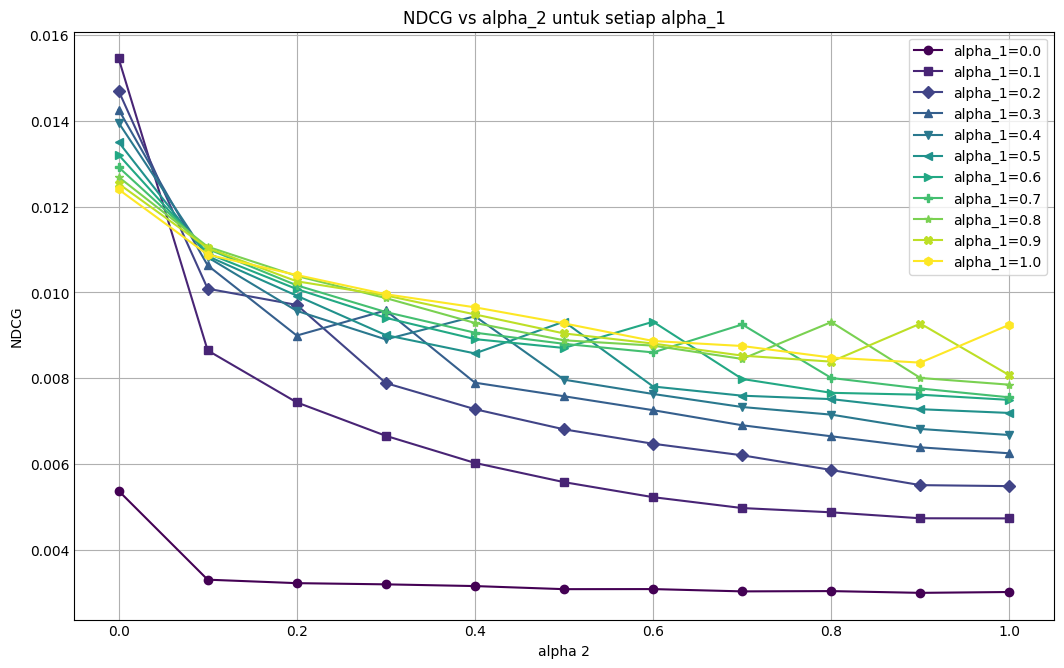

In [120]:
import pandas as pd

df = pd.DataFrame(mean_ndcg, index=[i for i in range(1, len(mean_dcg) + 1)], columns=["alpha 1", "alpha 2", "NDCG"])

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, df["alpha 1"].nunique()))
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'P', '*', 'X', 'h']  # Add more if needed

for idx, alpha1 in enumerate(sorted(df["alpha 1"].unique())):
    subset = df[df["alpha 1"] == alpha1]
    marker = markers[idx % len(markers)]
    plt.plot(subset["alpha 2"], subset["NDCG"], marker=marker, label=f'alpha_1={alpha1}', color=colors[idx], linestyle='-')

plt.xlabel("alpha 2")
plt.ylabel("NDCG")
plt.title("NDCG vs alpha_2 untuk setiap alpha_1")
plt.legend()
plt.grid(True)
plt.show()

### Skenario 2 : Mencari $k^{user}$ terbaik

In [6]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S

param = {
            "gamma" : [0.7],
            "k_user" : [5,10,15,18,20,25,30,40,50,100,200],
            "k_item" : [30],
            "alpha_1" : [0.1],
            "alpha_2" : [0],
        }

skenario_kedua = EksperimenHCF("data/ml-100k",object=S.TI,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],alpha_1=param["alpha_1"],alpha_2=param["alpha_2"],path_file="Eksperimen/tversky_index/FBO_K_user.joblib",N=20,n=20)

In [69]:
import numpy as np

n = 20
idcg = np.array([sum(np.array([sum(1/np.log2(np.arange(2,n+2))) for n in range(1,n+1)])) for i in range(1,n+1)])
k_user = [5,10,15,18,20,25,30,40,50,100,200]


mean_dcg_fold = []
mean_ndcg_fold = []
mean_dcg = []
mean_ndcg = []

for k_user_index in k_user :

    skenario_kedua_k_user = skenario_kedua.result_skenario[0.7][k_user_index][30][0.1][0]
    mean_dcg_per_fold = []
    mean_ndcg_per_fold = []

    for i in range(len(skenario_kedua_k_user)) :
        mean_dcg_per_fold += [sum(skenario_kedua_k_user[i])/len(skenario_kedua_k_user[i])]
        mean_ndcg_per_fold += [sum(np.array(skenario_kedua_k_user[i])/idcg[n-1])/len(skenario_kedua_k_user[i])]
    
    mean_dcg_per_fold += [sum(mean_dcg_per_fold)/len(skenario_kedua_k_user)]
    mean_ndcg_per_fold += [sum(mean_ndcg_per_fold)/len(skenario_kedua_k_user)]

    mean_dcg_fold += [mean_dcg_per_fold]
    mean_ndcg_fold += [mean_ndcg_per_fold]
    mean_dcg += [[k_user_index,30,sum(mean_dcg_per_fold)/len(skenario_kedua_k_user)]]
    mean_ndcg += [[k_user_index,30,sum(mean_ndcg_per_fold)/len(skenario_kedua_k_user)]]

#### DCG $k^{user}$ per fold 

In [74]:
import pandas as pd
k_user = [5,10,15,18,20,25,30,40,50,100,200]

pd.DataFrame(mean_dcg_fold,index=[ f"A1_{str(0.1)}_A2_{str(0)}_N_{i}" for i in k_user],columns=[f"fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,fold-1,fold-2,fold-3,fold-4,fold-5,rata-rata
A1_0.1_A2_0_N_5,6.120393,3.402389,3.680902,3.101523,2.501807,3.761403
A1_0.1_A2_0_N_10,6.473667,3.049781,2.972159,2.903736,2.034128,3.486694
A1_0.1_A2_0_N_15,6.384138,2.965078,2.748774,2.703529,1.712103,3.302724
A1_0.1_A2_0_N_18,6.020117,2.972633,2.569505,2.563572,1.635921,3.152350
A1_0.1_A2_0_N_20,6.014967,2.714146,2.553658,2.470527,1.481215,3.046903
A1_0.1_A2_0_N_25,5.621949,2.429720,2.271514,2.273340,1.321668,2.783638
A1_0.1_A2_0_N_30,5.386251,2.338132,1.930890,1.993669,1.129013,2.555591
A1_0.1_A2_0_N_40,5.031219,2.298457,1.618864,1.802431,0.869656,2.324125
A1_0.1_A2_0_N_50,4.451435,1.969877,1.382566,1.690813,0.706774,2.040293
A1_0.1_A2_0_N_100,3.038008,1.143685,0.644841,1.015593,0.374698,1.243365


#### $k^{user}$ per fold

In [75]:
import pandas as pd
k_user = [5,10,15,18,20,25,30,40,50,100,200]

pd.DataFrame(mean_ndcg_fold,index=[ f"A1_{str(0.1)}_A2_{str(0)}_N_{i}" for i in k_user],columns=[f"fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,fold-1,fold-2,fold-3,fold-4,fold-5,rata-rata
A1_0.1_A2_0_N_5,0.068312,0.037975,0.041084,0.034617,0.027923,0.041982
A1_0.1_A2_0_N_10,0.072255,0.034040,0.033173,0.032409,0.022704,0.038916
A1_0.1_A2_0_N_15,0.071255,0.033094,0.030680,0.030175,0.019109,0.036863
A1_0.1_A2_0_N_18,0.067192,0.033178,0.028679,0.028613,0.018259,0.035184
A1_0.1_A2_0_N_20,0.067135,0.030293,0.028502,0.027574,0.016532,0.034007
A1_0.1_A2_0_N_25,0.062748,0.027119,0.025353,0.025373,0.014752,0.031069
A1_0.1_A2_0_N_30,0.060118,0.026097,0.021551,0.022252,0.012601,0.028524
A1_0.1_A2_0_N_40,0.056155,0.025654,0.018069,0.020117,0.009706,0.025940
A1_0.1_A2_0_N_50,0.049684,0.021986,0.015431,0.018872,0.007889,0.022772
A1_0.1_A2_0_N_100,0.033908,0.012765,0.007197,0.011335,0.004182,0.013878


#### DCG $k^{user}$ Plot

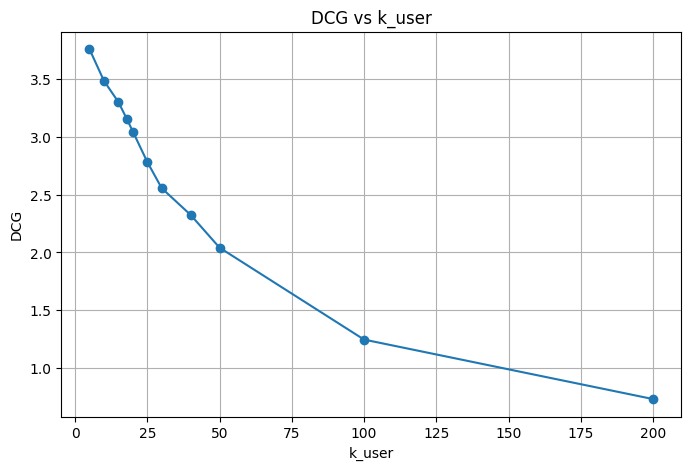

In [21]:
import pandas as pd

df = pd.DataFrame(mean_dcg, index=[i for i in range(1, len(mean_dcg) + 1)], columns=["k_user", "k_item", "DCG"])

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot([5,10,15,18,20,25,30,40,50,100,200], df["DCG"], marker='o')
plt.xlabel("k_user")
plt.ylabel("DCG")
plt.title("DCG vs k_user")
plt.grid(True)
plt.show()

#### NDCG $k^{user}$ Plot

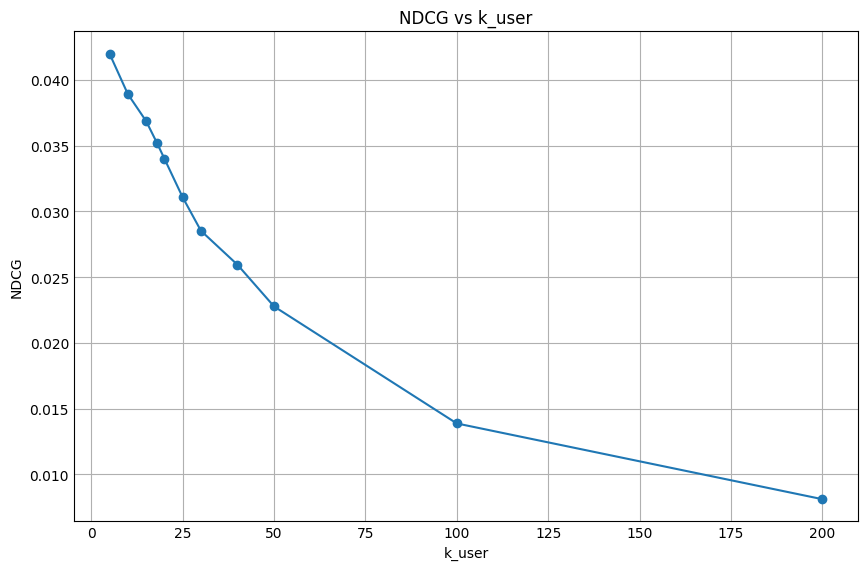

In [30]:
import pandas as pd

df = pd.DataFrame(mean_ndcg, index=[i for i in range(1, len(mean_ndcg) + 1)], columns=["k_user", "k_item", "NDCG"])

import matplotlib.pyplot as plt

plt.style.use("_mpl-gallery")

plt.figure(figsize=(8, 5))
plt.plot([5,10,15,18,20,25,30,40,50,100,200], df["NDCG"], marker='o')
plt.xlabel("k_user")
plt.ylabel("NDCG")
plt.title("NDCG vs k_user")
plt.grid(True)
plt.show()

### Skenario 3 : Mencari $k^{item}$ terbaik

In [ ]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S

param = {
            "gamma" : [0.7],
            "k_user" : [5],
            "k_item" : [5,10,15,18,20,25,30,40,50,100,200],
            "alpha_1" : [0.1],
            "alpha_2" : [0],
        }

skenario_kedua = EksperimenHCF("data/ml-100k",object=S.TI,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],alpha_1=param["alpha_1"],alpha_2=param["alpha_2"],path_file="Eksperimen/tversky_index/FBO_K_item.joblib",N=20,n=20)

  0%|          | 0/11 [00:00<?, ?it/s]